In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

df_geolife = pd.read_csv(f'./data/Geolife/20260720_geolife_database_metrics.csv')
df_rmove = pd.read_csv(f'./data/rMove/20260720_rmove_database_metrics.csv')

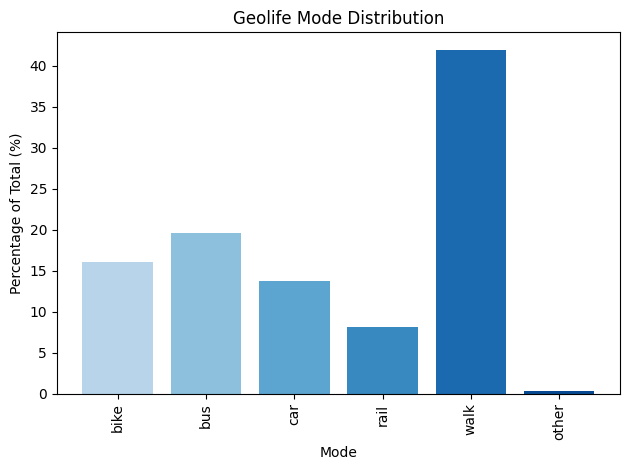

In [2]:
# Display GeoLife Counts, separated by mode of transportation

fig, ax = plt.subplots()

# Gives percentages of each mode
counts_per_mode = df_geolife['actual_mode'].value_counts(normalize=True)

# Combine similar modes
counts_per_mode['car'] = counts_per_mode['car'] + counts_per_mode['taxi']
counts_per_mode = counts_per_mode.drop(['taxi'])
counts_per_mode['rail'] = counts_per_mode['subway'] + counts_per_mode['train']
counts_per_mode = counts_per_mode.drop(['subway', 'train'])

# Filter to only desired modes
modes_to_include = ['bike', 'bus', 'car', 'rail', 'walk']
counts_per_mode['other'] = counts_per_mode[~counts_per_mode.index.isin(modes_to_include)].sum()
counts_per_mode = counts_per_mode[counts_per_mode.index.isin(modes_to_include + ['other'])]

counts_per_mode = counts_per_mode.sort_index()
other = counts_per_mode.pop('other')
counts_per_mode = pd.concat([counts_per_mode, pd.Series({'other': other})])

counts_per_mode_geolife = counts_per_mode.copy()

# Graph
ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts_per_mode))))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, symbol=None, decimals=0))
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Mode')
ax.set_ylabel('Percentage of Total (%)')
ax.set_title('Geolife Mode Distribution')
fig.tight_layout()

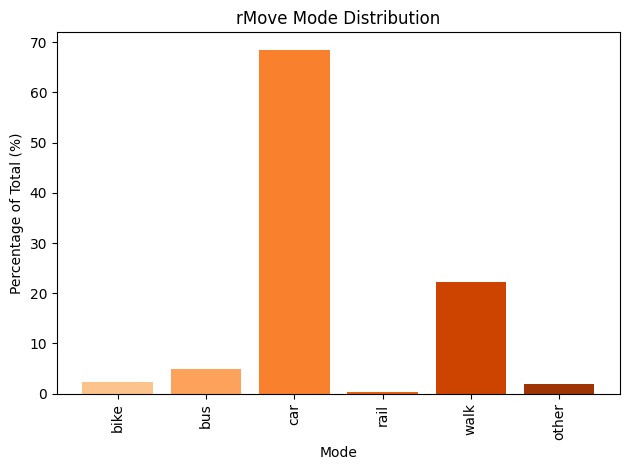

In [3]:
# Display rMove Counts, separated by mode of transportation

from src.map_terminology import map_rmove_to_generic_mode

fig, ax = plt.subplots()

# Gives percentages of each mode
df_rmove['actual_mode'] = df_rmove['actual_mode'].map(map_rmove_to_generic_mode)
counts_per_mode = df_rmove['actual_mode'].value_counts(normalize=True)

counts_per_mode = counts_per_mode.sort_index()

# Filter to only desired modes
modes_to_include = ['bike', 'bus', 'car', 'rail', 'walk']
counts_per_mode['other'] = counts_per_mode[~counts_per_mode.index.isin(modes_to_include)].sum()
counts_per_mode = counts_per_mode[counts_per_mode.index.isin(modes_to_include + ['other'])]

other = counts_per_mode.pop('other')
counts_per_mode = pd.concat([counts_per_mode, pd.Series({'other': other})])

counts_per_mode_rmove = counts_per_mode.copy()

# Graph
ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.Oranges(np.linspace(0.3, 0.9, len(counts_per_mode))))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, symbol=None, decimals=0))
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Mode')
ax.set_ylabel('Percentage of Total (%)')
ax.set_title('rMove Mode Distribution')
fig.tight_layout()

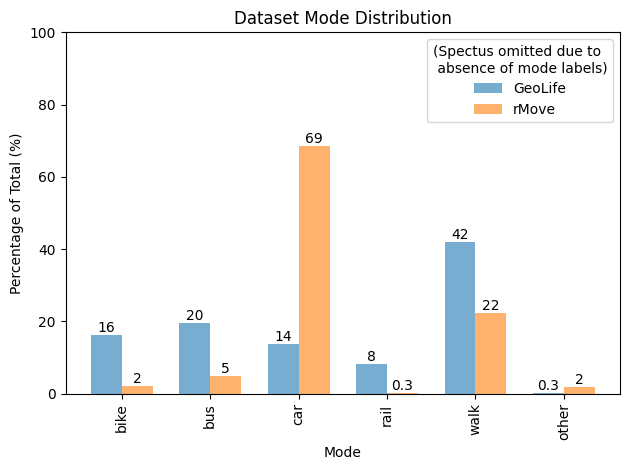

In [38]:
# Combine figures into a single graph

fig, ax = plt.subplots()

# Set up x positions and bar width
x = np.arange(len(counts_per_mode_geolife))  # [0, 1, 2, 3]
width = 0.35  # width of each bar

geolife_bar = ax.bar(x - width/2,
                     counts_per_mode_geolife.values,
                     width,
                     color='C0',
                     alpha=0.6,
                     label='GeoLife')

rmove_bar = ax.bar(x + width/2,
                   counts_per_mode_rmove.values,
                   width,
                   color='C1',
                   alpha=0.6,
                   label='rMove')

def format_value(v):
    percent = v * 100
    return f'{percent:.1f}' if percent < 1 else f'{percent:.0f}'

ax.bar_label(geolife_bar, labels=[format_value(v) for v in counts_per_mode_geolife.values])
ax.bar_label(rmove_bar, labels=[format_value(v) for v in counts_per_mode_rmove.values])

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, symbol=None, decimals=0))
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(x)
ax.set_xticklabels(counts_per_mode_geolife.index)

ax.set_xlabel('Mode')
ax.set_ylabel('Percentage of Total (%)')
ax.set_title('Dataset Mode Distribution')
ax.legend(title=f"(Spectus omitted due to\n absence of mode labels)")

fig.tight_layout()
fig.savefig("images/Mode_Distribution.png", dpi=200)